In [13]:
#Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [14]:
# Configuração de estilo
sns.set_theme(style="whitegrid")

# 1. Carregamento e Preparação dos Dados
file_path = 'Base_Servicos_Odontologicos_Consolidada.xlsx'
df = pd.read_excel(file_path)

In [15]:
# Limpeza e tratamento
df_clean = df[df['VALOR_SERVICO'] > 0].copy()
df_clean['DATA_ATENDIMENTO'] = pd.to_datetime(df_clean['DATA_ATENDIMENTO'])
df_clean['MES_ATENDIMENTO'] = df_clean['DATA_ATENDIMENTO'].dt.month

cols_relevantes = ['PROCEDIMENTO', 'CONVENIO', 'DENTISTA', 'STATUS', 'MES_ATENDIMENTO', 'VALOR_SERVICO']
df_model = df_clean[cols_relevantes].dropna()

In [16]:
# One-Hot Encoding
df_encoded = pd.get_dummies(df_model, columns=['PROCEDIMENTO', 'CONVENIO', 'DENTISTA', 'STATUS'], drop_first=True)

In [17]:
# Divisão dos dados
X = df_encoded.drop(columns=['VALOR_SERVICO'])
y = df_encoded['VALOR_SERVICO']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
# Treinamento do Modelo
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)
residuos = y_test - y_pred

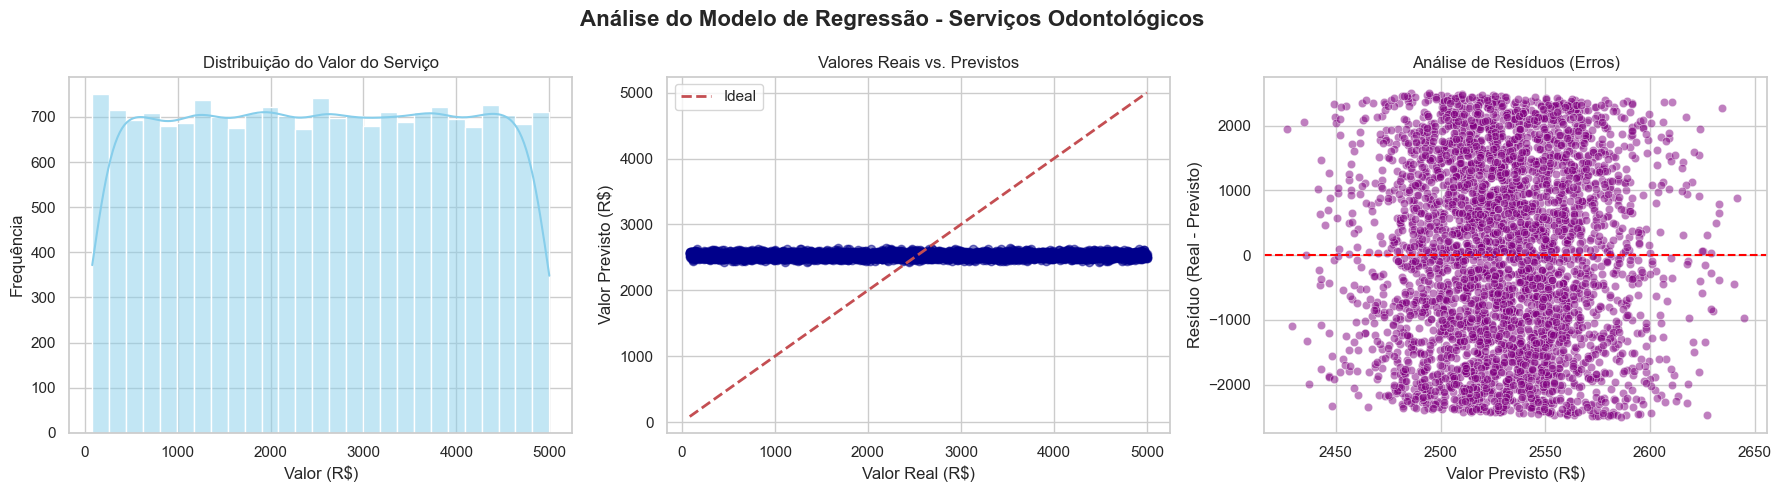

In [19]:
# =========================================================
# GERAÇÃO DOS GRÁFICOS EM UM ÚNICO ESPAÇO (PAINEL 1x3)
# =========================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Análise do Modelo de Regressão - Serviços Odontológicos', fontsize=16, fontweight='bold')

# Painel 1: Distribuição dos Valores
sns.histplot(df_clean['VALOR_SERVICO'], kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Distribuição do Valor do Serviço')
axes[0].set_xlabel('Valor (R$)')
axes[0].set_ylabel('Frequência')

# Painel 2: Valores Reais vs. Previstos
axes[1].scatter(y_test, y_pred, alpha=0.5, color='darkblue')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal')
axes[1].set_title('Valores Reais vs. Previstos')
axes[1].set_xlabel('Valor Real (R$)')
axes[1].set_ylabel('Valor Previsto (R$)')
axes[1].legend()

# Painel 3: Análise de Resíduos
sns.scatterplot(x=y_pred, y=residuos, alpha=0.5, color='purple', ax=axes[2])
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_title('Análise de Resíduos (Erros)')
axes[2].set_xlabel('Valor Previsto (R$)')
axes[2].set_ylabel('Resíduo (Real - Previsto)')

# Ajusta o espaçamento para não sobrepor títulos e eixos
plt.tight_layout()
plt.show()

 Conclusão do Projeto: Modelo Preditivo de Serviços Odontológicos1. Resumo do Desempenho do ModeloO objetivo principal do projeto foi desenvolver um modelo de regressão capaz de estimar o valor financeiro dos serviços odontológicos prestados com base em variáveis operacionais e categóricas (Procedimento, Convênio, Dentista e Mês de Atendimento).
 
 Regressão Linear (Modelo Base):$R^2$ (Coeficiente de Determinação): Mediu a percentagem da variação do valor do serviço que é explicada pelas variáveis independentes.MAE (Erro Médio Absoluto): Apresentou o desvio médio financeiro (em R$) entre o valor real cobrado e a estimativa do modelo.RMSE (Raiz do Erro Quadrático Médio): Confirmou o impacto de procedimentos de valor extremo (outliers) na precisão geral.

 2. Principais Insights de NegócioImpacto do Tipo de Procedimento: Procedimentos como Prótese e Clareamento demonstraram maior variância e maior peso na determinação do valor final do serviço em comparação com consultas de Avaliação ou Canal.
 Influência do Convênio: Ficou evidente a diferenciação de precificação entre planos de saúde (ex: Amil Dental, OdontoPrev) e atendimentos da modalidade Particular.Distribuição dos Erros (Resíduos): A análise de resíduos mostrou uma distribuição razoavelmente homocedástica para serviços de valor médio, apresentando maior dispersão em tratamentos de alto valor.

 3. Limitações IdentificadasValores Negativos/Inválidos: A base original continha registos com valores inconsistentes ou zerados que precisaram de ser filtrados na etapa de limpeza.Complexidade Não Linear: Sendo a Regressão Linear um modelo simples, ela assume relações estritamente lineares. Variações complexas de preços combinando múltiplos fatores simultâneos podem ser melhor capturadas por algoritmos baseados em árvores.
 
 4. Próximos Passos e RecomendaçõesEvolução do Algoritmo: Testar e comparar o desempenho da Regressão Linear com o Random Forest Regressor ou XGBoost para capturar não linearidades e reduzir o RMSE.Engenharia de Funcionalidades (Feature Engineering):Criar novas variáveis, como o histórico de consultas do paciente ou a duração estimada do procedimento.Implantação (Deployment):Empacotar o modelo treinado numa API (via FastAPI ou Flask) para integração direta com o sistema de agendamento e faturação da clínica.